# Analiza i Klasterizacija E-commerce Prodaje
### Amazon Sale Report — Segmentacija Kupaca pomocu Nenadgledanog Ucenja

---
> **Autor:** Aleksandra Djokic  
> **Predmet:** Masinsko ucenje  
> **Dataset:** Amazon Sale Report (128,975 transakcija)

## 1. Cilj projekta

Cilj projekta je segmentacija kupaca na osnovu transakcionih podataka koristeci nenadgledano ucenje.

U radu poredimo vise algoritama klasterizacije, biramo optimalan broj klastera i profilisemo segmente kroz jasne poslovne preporuke.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import train_test_split, ShuffleSplit
from scipy.cluster.hierarchy import dendrogram, linkage

In [17]:
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 2. Ucitavanje i ciscenje podataka

In [18]:
data = pd.read_csv('Amazon Sale Report.csv', low_memory=False)
data.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [20]:
data.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

### 2.1. Ciscenje podataka

Uklanjamo nepotrebne kolone, redove sa nedostajucim vrednostima za `Amount` i konvertujemo `Date` u datetime format.

In [21]:

cols_to_drop = ['promotion-ids', 'Unnamed: 22', 'fulfilled-by', 'ship-country']
data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

data.dropna(subset=['Amount'], inplace=True)

data['Date'] = pd.to_datetime(data['Date'])

## 3. Eksplorativna analiza podataka (EDA)

Pre predobrade, analiziramo osnovne karakteristike podataka: vremenske trendove, distribuciju kategorija i kreiranje novih obelezja.

     Month  Ukupna_prodaja  Broj_porudzbina Month_str
0  2022-03       101683.85              162   2022-03
1  2022-04     28838708.32            46068   2022-04
2  2022-05     26226476.75            39536   2022-05
3  2022-06     23425809.38            35414   2022-06


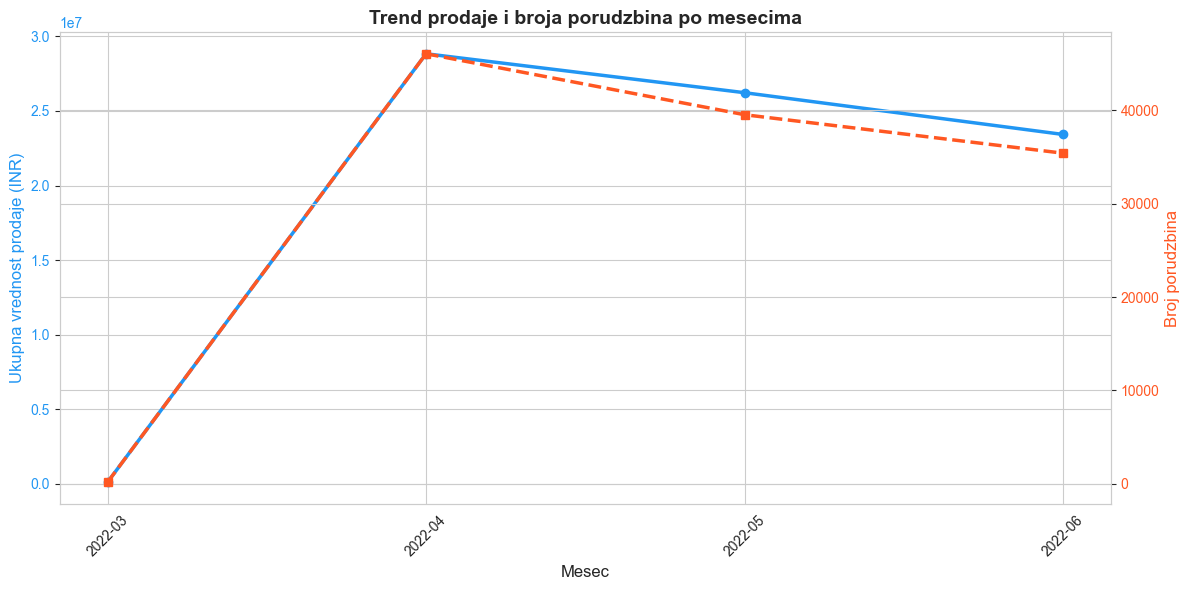

In [22]:
# Analiza vremenskih trendova (Prodaja po mesecima)
data['Month'] = data['Date'].dt.to_period('M')

monthly_stats = data.groupby('Month').agg(
    Ukupna_prodaja=('Amount', 'sum'),
    Broj_porudzbina=('Amount', 'count')
).reset_index()
monthly_stats['Month_str'] = monthly_stats['Month'].astype(str)

print(monthly_stats)

# Vizualizacija: prodaja i broj porudzbina
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Mesec', fontsize=12)
ax1.set_ylabel('Ukupna vrednost prodaje (INR)', color='#2196F3', fontsize=12)
ax1.plot(monthly_stats['Month_str'], monthly_stats['Ukupna_prodaja'],
         color='#2196F3', marker='o', linewidth=2.5, label='Ukupna prodaja')
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Broj porudzbina', color='#FF5722', fontsize=12)
ax2.plot(monthly_stats['Month_str'], monthly_stats['Broj_porudzbina'],
         color='#FF5722', marker='s', linewidth=2.5, linestyle='--', label='Broj porudzbina')
ax2.tick_params(axis='y', labelcolor='#FF5722')

plt.title('Trend prodaje i broja porudzbina po mesecima', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

 Tabela Kardinalnosti 
    Kolona  Broj jedinstvenih vrednosti
  Category                            9
      Size                           11
 ship-city                         8704
ship-state                           68


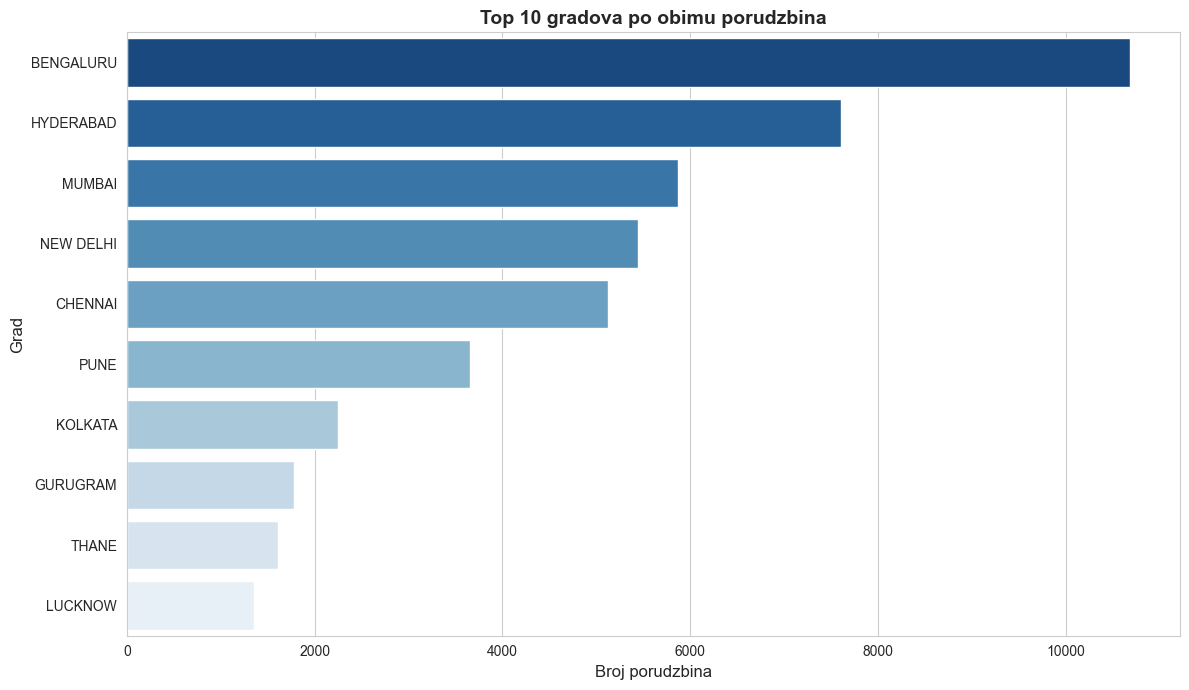

In [23]:
#distribucija kategorija
cardinality_cols = ['Category', 'Size', 'ship-city', 'ship-state']
cardinality_df = pd.DataFrame({
    'Kolona': cardinality_cols,
    'Broj jedinstvenih vrednosti': [data[col].nunique() for col in cardinality_cols]
})
print(' Tabela Kardinalnosti ')
print(cardinality_df.to_string(index=False))

# Top 10 gradova po broju porudzbina
top10_cities = data['ship-city'].value_counts().head(10).reset_index()
top10_cities.columns = ['Grad', 'Broj porudzbina']

plt.figure(figsize=(12, 7))
sns.barplot(data=top10_cities, x='Broj porudzbina', y='Grad', palette='Blues_r')
plt.title('Top 10 gradova po obimu porudzbina', fontsize=14, fontweight='bold')
plt.xlabel('Broj porudzbina', fontsize=12)
plt.ylabel('Grad', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
# Feature Engineering (Total Revenue)
# Amount u ovom skupu predstavlja vrednost transakcije, pa ga koristimo direktno kao prihod.
data['Total_Revenue'] = data['Amount']

print('=== Prvih 5 redova sa kolonom Total_Revenue ===')
print(data[['Qty', 'Amount', 'Total_Revenue']].head())
print(f'\nUkupan prihod u datasetu: {data["Total_Revenue"].sum():,.2f} INR')
print(f'Prosecan prihod po transakciji: {data["Total_Revenue"].mean():,.2f} INR')

=== Prvih 5 redova sa kolonom Total_Revenue ===
   Qty  Amount  Total_Revenue
0    0  647.62         647.62
1    1  406.00         406.00
2    1  329.00         329.00
3    0  753.33         753.33
4    1  574.00         574.00

Ukupan prihod u datasetu: 78,592,678.30 INR
Prosecan prihod po transakciji: 648.56 INR


## 4. Predobrada podataka

### 4.1. Detekcija i obrada outliera (Winsorizacija)

Outlieri u koloni `Amount` mogu drasticno pomeriti centroid klastera. Zato koristimo Winsorizaciju, sve vrednosti iznad 95. percentila se spustaju na vrednost 95. percentila:

```
Pre:   [50, 200, 450, 600, 800, 15.000]  ← outlier remeti centroid
Posle: [50, 200, 450, 600, 800,  1.176]  ← vrednost 'sabijena' na 95. percentil
```


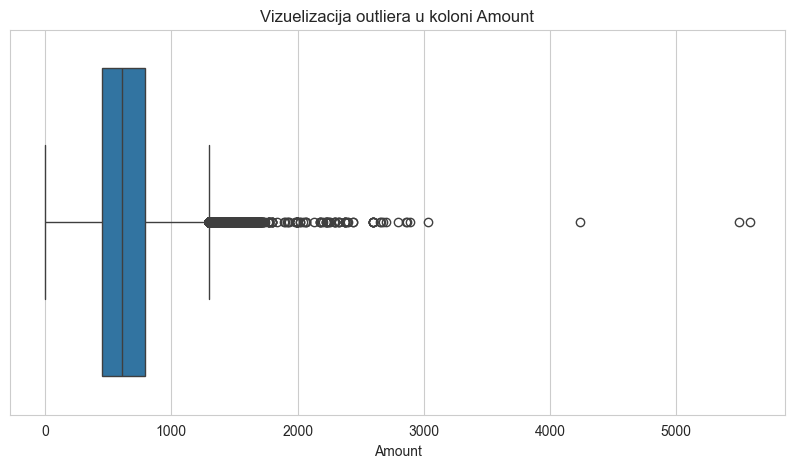

In [25]:

plt.figure(figsize=(10, 5))
sns.boxplot(x=data['Amount'])
plt.title('Vizuelizacija outliera u koloni Amount')
plt.show()

In [26]:
# Leak-free vinsorizacija: prag racunamo samo na train delu
np.random.seed(42)
row_idx = data.index.to_numpy()
train_rows, test_rows = train_test_split(row_idx, test_size=0.2, random_state=42)

amount_cap_train = data.loc[train_rows, 'Amount'].quantile(0.95)
data['Amount'] = data['Amount'].clip(upper=amount_cap_train)

print(f"Train redova: {len(train_rows)}, Test redova: {len(test_rows)}")
print(f"95. percentil izracunat SAMO na train skupu: {amount_cap_train:.2f}")

Train redova: 96944, Test redova: 24236
95. percentil izracunat SAMO na train skupu: 1176.00


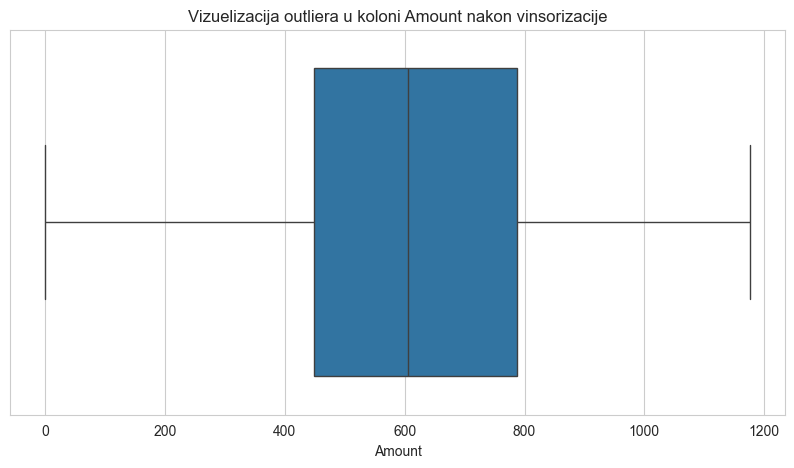

In [27]:

data.describe()
plt.figure(figsize=(10, 5))
sns.boxplot(x=data['Amount'])
plt.title('Vizuelizacija outliera u koloni Amount nakon vinsorizacije')
plt.show()

### 4.2. Kodiranje i skaliranje podataka

In [28]:
# Kodiranje kategorijskih obelezja bez uvodjenja lazne ordinalnosti
cat_cols = ['Category', 'Size', 'Courier Status']
num_cols = ['Qty', 'Amount']
binary_cols = ['B2B']

X = data[cat_cols + num_cols + binary_cols].copy()
X[cat_cols] = X[cat_cols].fillna('Unknown')
X[binary_cols] = X[binary_cols].astype(int)

# One-hot kodiranje za nominalne kategorijske promenljive
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Provera i uklanjanje NaN vrednosti
print(f"Broj NaN vrednosti pre ciscenja: {X.isna().sum().sum()}")
X_clean = X.dropna()
print(f"Dimenzije nakon uklanjanja NaN: {X_clean.shape}")

# Cuvamo indekse posle ciscenja da bismo mogli da mapiramo klastere nazad na originalne podatke
clean_indices = X_clean.index

# Split pre skaliranja: scaler fit samo na train delu
idx_all = np.arange(len(X_clean))
train_idx, valid_idx = train_test_split(idx_all, test_size=0.2, random_state=42)

X_train_raw = X_clean.iloc[train_idx]
X_valid_raw = X_clean.iloc[valid_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_valid_scaled = scaler.transform(X_valid_raw)
X_scaled = scaler.transform(X_clean)

print(f"Train (modeling): {X_train_scaled.shape}, Valid (modeling): {X_valid_scaled.shape}")
X_scaled[:5]

Broj NaN vrednosti pre ciscenja: 0
Dimenzije nakon uklanjanja NaN: (121180, 26)
Train (modeling): (96944, 26), Valid (modeling): (24236, 26)


array([[-4.47905469e+00,  2.65218763e-02, -8.27300696e-02,
        -8.61378174e-02, -5.81764347e-02, -4.54212425e-03,
        -9.58753142e-02, -3.62181322e-02,  1.25393218e+00,
        -3.02534844e-01, -3.70314737e-01, -7.92256005e-01,
        -3.59589098e-01, -5.93255679e-02, -6.63572009e-02,
        -7.67016714e-02, -5.45860709e-02, -4.57219217e-01,
        -4.61533328e-01,  2.57064676e+00, -4.40581676e-01,
        -3.04662598e-01, -4.05731928e-01, -3.05553321e+00,
         4.76595066e+00, -2.40267781e-01],
       [ 1.79381308e-01, -9.09042260e-01, -8.27300696e-02,
        -8.61378174e-02, -5.81764347e-02, -4.54212425e-03,
        -9.58753142e-02, -3.62181322e-02, -7.97491299e-01,
        -3.02534844e-01, -3.70314737e-01,  1.26221827e+00,
         2.78095194e+00, -5.93255679e-02, -6.63572009e-02,
        -7.67016714e-02, -5.45860709e-02, -4.57219217e-01,
        -4.61533328e-01, -3.89007162e-01, -4.40581676e-01,
        -3.04662598e-01, -4.05731928e-01,  3.27275121e-01,
        -2.09

## 5. Redukcija dimenzionalnosti (PCA)

Broj ulaznih obelezja nakon one-hot kodiranja: 26
Explained Variance Ratio: [0.09755847 0.08391642]
Ukupno zadrzano: 18.15% informacija


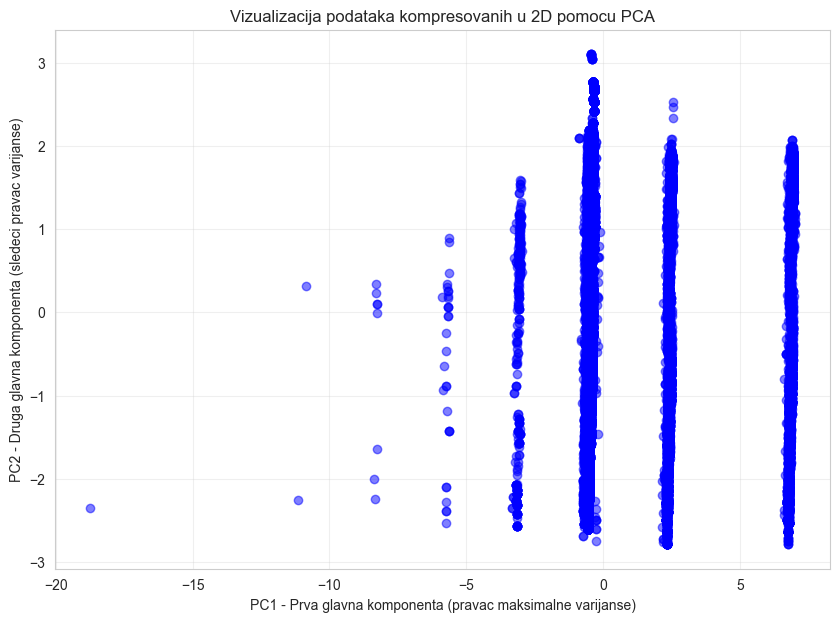

In [29]:
# Inicijalizacija PCA sa 2 komponente
print(f"Broj ulaznih obelezja nakon one-hot kodiranja: {X_scaled.shape[1]}")
pca = PCA(n_components=2)

# Transformacija skaliranih podataka u 2D prostor
X_pca = pca.fit_transform(X_scaled)

# Ispis objasnjene varijanse
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Ukupno zadrzano: {sum(pca.explained_variance_ratio_)*100:.2f}% informacija")

# Vizualizacija 
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', alpha=0.5)
plt.xlabel('PC1 - Prva glavna komponenta (pravac maksimalne varijanse)')
plt.ylabel('PC2 - Druga glavna komponenta (sledeci pravac varijanse)')
plt.title('Vizualizacija podataka kompresovanih u 2D pomocu PCA')
plt.grid(alpha=0.3)
plt.show()

### 5.1. Napredna vizualizacija: PCA vs t-SNE vs UMAP


In [ ]:
from sklearn.manifold import TSNE
import umap

# Koristimo uzorak do 5000 redova jer su t-SNE i UMAP racunski zahtevni
np.random.seed(42)
viz_size = min(5000, len(X_scaled))
viz_sample_idx = np.random.choice(len(X_scaled), viz_size, replace=False)
X_viz_scaled = X_scaled[viz_sample_idx]
X_viz_pca = X_pca[viz_sample_idx]

if 'best_k' not in globals():
    k_search_space = range(2, 11)
    X_for_k = X_train_scaled if 'X_train_scaled' in globals() else X_scaled

    best_k_tmp = None
    best_sil_tmp = -1

    for k in k_search_space:
        km_tmp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels_tmp = km_tmp.fit_predict(X_for_k)
        if len(np.unique(labels_tmp)) < 2:
            continue
        sil_tmp = silhouette_score(X_for_k, labels_tmp)
        if sil_tmp > best_sil_tmp:
            best_sil_tmp = sil_tmp
            best_k_tmp = k

    best_k = best_k_tmp if best_k_tmp is not None else 2
    print(f"best_k nije bio definisan; automatski postavljen na {best_k} (fallback).")

# Ako finalne KMeans labele ne postoje ili nisu uskladjene sa best_k, treniramo ih ponovo.
if (
    'kmeans_labels' not in globals()
    or len(kmeans_labels) != len(X_scaled)
    or 'kmeans' not in globals()
    or getattr(kmeans, 'n_clusters', None) != best_k
):
    kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)

viz_labels = kmeans_labels[viz_sample_idx]

# t-SNE projekcija
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_viz_scaled)
print("t-SNE zavrsen.")

# UMAP projekcija
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_viz_scaled)
print("UMAP zavrsen.")

# Uporedna vizualizacija: PCA vs t-SNE vs UMAP
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cmap = plt.cm.viridis
titles = ['PCA (linearna)', 't-SNE (nelinearna)', 'UMAP (nelinearna)']
data_list = [X_viz_pca, X_tsne, X_umap]
xlabels = ['PC1', 't-SNE 1', 'UMAP 1']
ylabels = ['PC2', 't-SNE 2', 'UMAP 2']

for ax, X_proj, title, xl, yl in zip(axes, data_list, titles, xlabels, ylabels):
    scatter = ax.scatter(
        X_proj[:, 0], X_proj[:, 1], c=viz_labels,
        cmap=cmap, alpha=0.5, s=10, edgecolors='none'
    )
    ax.set_xlabel(xl, fontsize=11)
    ax.set_ylabel(yl, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.2)

fig.colorbar(
    scatter,
    ax=axes,
    label=f'K-Means Klaster ID (k={best_k})',
    ticks=sorted(np.unique(viz_labels)),
    shrink=0.8
)
plt.suptitle(
    'Poredjenje tehnika redukcije dimenzionalnosti (uzorak do 5000 tacaka)',
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

## 6. Klasterizacija

### 6.1. K-Means algoritam

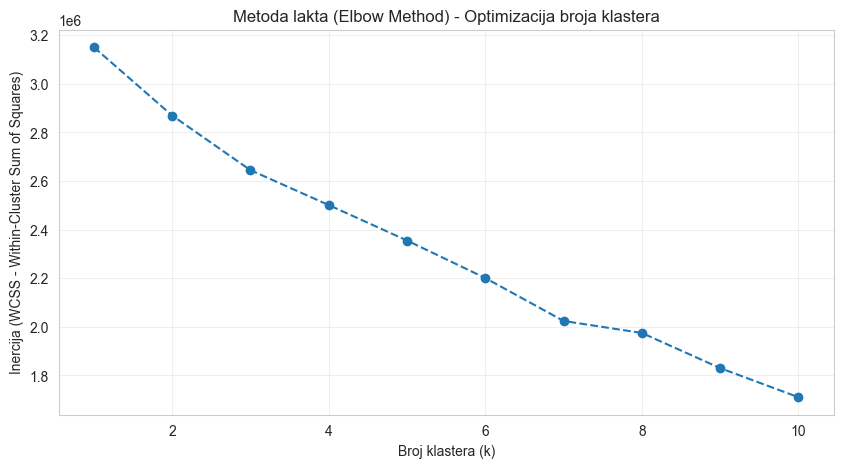

In [ ]:
# Elbow Method (na skaliranom punom prostoru obelezja)
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Vizualizacija Elbow krive
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metoda lakta (Elbow Method) - Optimizacija broja klastera')
plt.xlabel('Broj klastera (k)')
plt.ylabel('Inercija (WCSS - Within-Cluster Sum of Squares)')
plt.grid(alpha=0.3)
plt.show()

### 6.1.1. Izbor broja klastera (k) na osnovu metrika

U projektu evaluiramo vise vrednosti **k=2..10** na istom uzorku i biramo `best_k` kombinovanjem 3 metrike:

Metrike koje pratimo za kontrolu kvaliteta resenja su:

| Metrika | Interpretacija | Optimalna vrednost |
|---------|----------------|-------------------|
| **Silhouette Score** | Meri koliko su tacke unutar klastera blizu jedna drugoj u odnosu na tacke iz drugih klastera | Blize 1 je bolje (>0.5 = dobar) |
| **Calinski-Harabasz Index** | Odnos disperzije izmedju klastera i unutar klastera | Vece je bolje |
| **Davies-Bouldin Index** | Prosecna slicnost svakog klastera sa najslicnijim klasterom | Manje je bolje |

In [ ]:
# Stabilniji izbor k: ponovljeni splitovi na train delu (bez curenja informacija)
k_vals = range(2, 11)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

results_k = []

for k in k_vals:
    sil_scores, ch_scores, db_scores, inertia_scores = [], [], [], []

    for fold_i, (tr, va) in enumerate(cv.split(X_train_scaled), start=1):
        X_tr = X_train_scaled[tr]
        X_va = X_train_scaled[va]

        km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        km.fit(X_tr)
        labels_va = km.predict(X_va)

        # Metodoloska zastita: metrike zahtevaju >=2 klastera u validaciji
        if len(np.unique(labels_va)) < 2:
            continue

        sil_scores.append(silhouette_score(X_va, labels_va))
        ch_scores.append(calinski_harabasz_score(X_va, labels_va))
        db_scores.append(davies_bouldin_score(X_va, labels_va))
        inertia_scores.append(km.inertia_)

    results_k.append({
        'k': k,
        'Silhouette': np.mean(sil_scores),
        'Silhouette_std': np.std(sil_scores),
        'CH': np.mean(ch_scores),
        'CH_std': np.std(ch_scores),
        'DB': np.mean(db_scores),
        'DB_std': np.std(db_scores),
        'Inertia': np.mean(inertia_scores)
    })

    print(
        f"k={k}: Sil={np.mean(sil_scores):.4f}±{np.std(sil_scores):.4f}, "
        f"CH={np.mean(ch_scores):.2f}±{np.std(ch_scores):.2f}, "
        f"DB={np.mean(db_scores):.4f}±{np.std(db_scores):.4f}"
    )

# DataFrame metrika
df_k = pd.DataFrame(results_k)

# Kandidati po svakoj metrici (na srednjim vrednostima)
best_sil_row = df_k.sort_values('Silhouette', ascending=False).iloc[0]
best_ch_row = df_k.sort_values('CH', ascending=False).iloc[0]
best_db_row = df_k.sort_values('DB', ascending=True).iloc[0]

best_sil = int(best_sil_row['k'])
best_ch = int(best_ch_row['k'])
best_db = int(best_db_row['k'])

votes = {}
for cand in [best_sil, best_ch, best_db]:
    votes[cand] = votes.get(cand, 0) + 1

best_k = max(votes, key=votes.get)
print(f"\nPreporuceni k po vecinskom glasanju metrika (CV): {best_k}")
print(f"(Silhouette -> {best_sil}, CH -> {best_ch}, DB -> {best_db})")

df_k

k=2: Silhouette=0.4020, CH=494.65, DB=1.0544
k=3: Silhouette=0.1596, CH=483.16, DB=2.1632
k=4: Silhouette=0.1683, CH=545.90, DB=1.6218
k=5: Silhouette=0.1481, CH=488.14, DB=1.8405
k=6: Silhouette=0.1622, CH=503.95, DB=1.5550
k=7: Silhouette=0.2265, CH=494.83, DB=1.5397
k=8: Silhouette=0.2362, CH=464.72, DB=1.4258
k=9: Silhouette=0.2725, CH=488.75, DB=1.3055
k=10: Silhouette=0.3246, CH=516.83, DB=1.2509

Kandidat po Silhouette metrici: k=2


,k,Silhouette,CH,DB,Inertia
0,2,0.401980,494.654496,1.054405,118448.244422
1,3,0.159636,483.163126,2.163188,109077.565718
2,4,0.168305,545.898595,1.621751,98035.086485
3,5,0.148068,488.139437,1.840543,93587.777603
4,6,0.162211,503.954609,1.554994,86517.731361
5,7,0.226528,494.833157,1.539701,81630.810508
6,8,0.236194,464.716080,1.425803,78813.009816
7,9,0.272476,488.750746,1.305482,72989.961667
8,10,0.324580,516.828218,1.250905,67370.950083


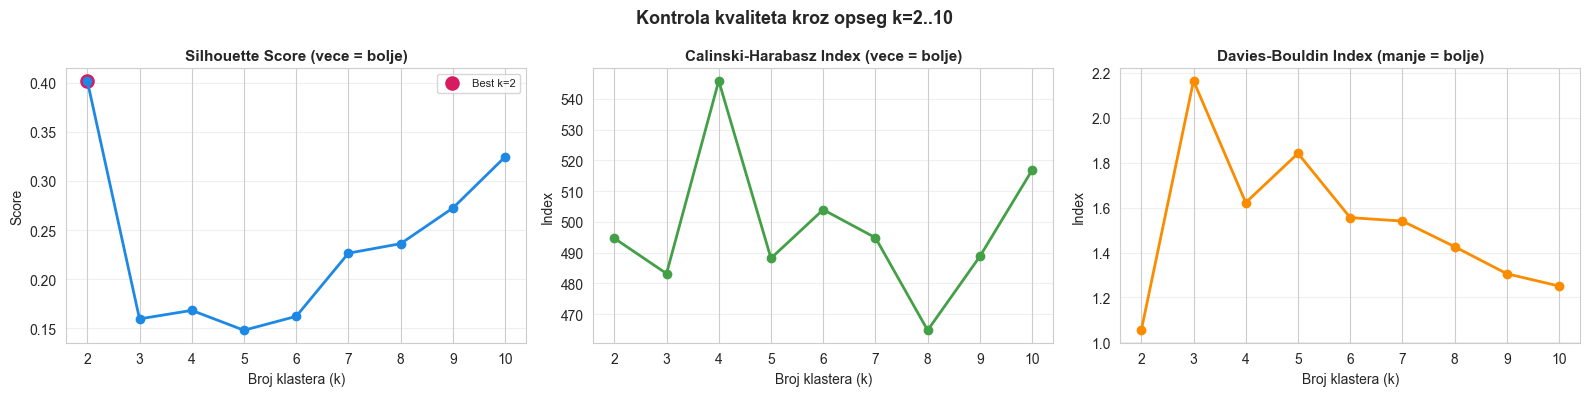

In [ ]:
# Vizuelizacija metrika kroz opseg k vrednosti
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Silhouette Score
ax = axes[0]
ax.plot(df_k['k'], df_k['Silhouette'], marker='o', linewidth=2, color='#1E88E5')
ax.scatter(best_k, df_k.loc[df_k['k'] == best_k, 'Silhouette'].values[0], color='#D81B60', s=90, label=f'Best k={best_k}')
ax.set_title('Silhouette Score (vece = bolje)', fontsize=11, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Broj klastera (k)')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)

# Calinski-Harabasz
ax = axes[1]
ax.plot(df_k['k'], df_k['CH'], marker='o', linewidth=2, color='#43A047')
ax.set_title('Calinski-Harabasz Index (vece = bolje)', fontsize=11, fontweight='bold')
ax.set_ylabel('Index')
ax.set_xlabel('Broj klastera (k)')
ax.grid(axis='y', alpha=0.3)

# Davies-Bouldin
ax = axes[2]
ax.plot(df_k['k'], df_k['DB'], marker='o', linewidth=2, color='#FB8C00')
ax.set_title('Davies-Bouldin Index (manje = bolje)', fontsize=11, fontweight='bold')
ax.set_ylabel('Index')
ax.set_xlabel('Broj klastera (k)')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Kontrola kvaliteta kroz opseg k=2..10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Zakljucak: Izbor broja klastera na osnovu stabilnosti metrika kroz vise splitova
print('=' * 90)
print('ZAKLJUCAK: IZBOR BROJA KLASTERA (CV NA TRAIN DELU)')
print('=' * 90)

display(df_k[['k', 'Silhouette', 'Silhouette_std', 'CH', 'CH_std', 'DB', 'DB_std', 'Inertia']])

best_row = df_k[df_k['k'] == best_k].iloc[0]
print(f"\nPreporuceni k po vecinskom glasanju: {best_k}")
print(
    f"CV metrike za k={best_k}: "
    f"Sil={best_row['Silhouette']:.4f}±{best_row['Silhouette_std']:.4f}, "
    f"CH={best_row['CH']:.2f}±{best_row['CH_std']:.2f}, "
    f"DB={best_row['DB']:.4f}±{best_row['DB_std']:.4f}"
)

# Hold-out validacija: treniramo na train, evaluiramo na valid
km_holdout = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
km_holdout.fit(X_train_scaled)
valid_labels = km_holdout.predict(X_valid_scaled)

if len(np.unique(valid_labels)) >= 2:
    holdout_sil = silhouette_score(X_valid_scaled, valid_labels)
    holdout_ch = calinski_harabasz_score(X_valid_scaled, valid_labels)
    holdout_db = davies_bouldin_score(X_valid_scaled, valid_labels)
    print(
        f"Hold-out metrike (valid): Sil={holdout_sil:.4f}, "
        f"CH={holdout_ch:.2f}, DB={holdout_db:.4f}"
    )
else:
    print('Hold-out validacija nije moguca: valid predikcije imaju <2 klastera.')

print('=' * 90)

ZAKLJUCAK: IZBOR BROJA KLASTERA


,k,Silhouette,CH,DB,Inertia
0,2,0.401980,494.654496,1.054405,118448.244422
1,3,0.159636,483.163126,2.163188,109077.565718
2,4,0.168305,545.898595,1.621751,98035.086485
3,5,0.148068,488.139437,1.840543,93587.777603
4,6,0.162211,503.954609,1.554994,86517.731361
5,7,0.226528,494.833157,1.539701,81630.810508
6,8,0.236194,464.716080,1.425803,78813.009816
7,9,0.272476,488.750746,1.305482,72989.961667
8,10,0.324580,516.828218,1.250905,67370.950083



Preporuceni k po vecinskom glasanju metrika: 2
(Silhouette -> 2, CH -> 4, DB -> 2)
Metrike za k=2: Silhouette=0.4020, CH=494.65, DB=1.0544


In [ ]:
# Treniranje finalnog K-Means modela na celom skupu (nakon sto je best_k izabran bez curenja)
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

data.loc[clean_indices, 'Cluster_KMeans'] = kmeans_labels

print(f"K-Means koristi best_k={best_k}")
print("Broj transakcija po klasteru:")
print(data['Cluster_KMeans'].value_counts().sort_index())

# Jedinstven, konzistentan uzorak za sve komparativne analize (k-selekcija/DBSCAN/battle)
np.random.seed(42)
comparison_size = min(5000, len(X_scaled))
comparison_idx = np.random.choice(len(X_scaled), comparison_size, replace=False)
X_comparison = X_scaled[comparison_idx]
X_comparison_pca = X_pca[comparison_idx]

print(f"Konzistentan uzorak za poredjenja: {X_comparison.shape[0]} redova")

K-Means koristi best_k=2
Broj transakcija po klasteru:
Cluster_KMeans
0.0    109516
1.0     11664
Name: count, dtype: int64


### 6.2. Hijerarhijska klasterizacija

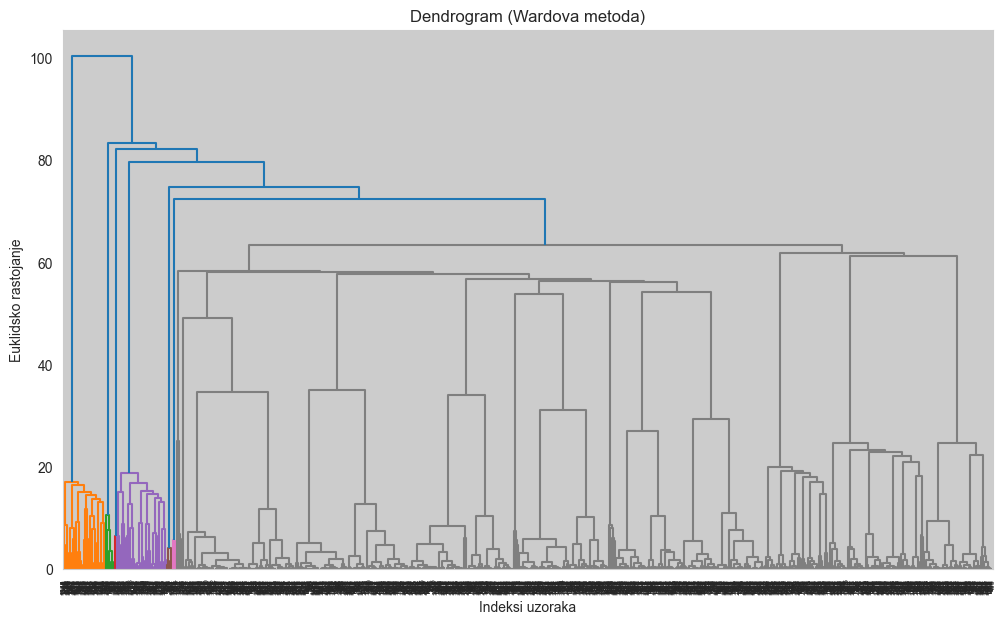

Hijerarhijski model koristi best_k=2


In [ ]:
# Hijerarhijska analiza na konzistentnom uzorku (X_comparison)
if 'X_comparison' not in globals():
    np.random.seed(42)
    comparison_size = min(5000, len(X_scaled))
    comparison_idx = np.random.choice(len(X_scaled), comparison_size, replace=False)
    X_comparison = X_scaled[comparison_idx]

# Dendrogram na poduzorku ISTOG skupa
np.random.seed(42)
dendro_size = min(2000, len(X_comparison))
dendro_idx = np.random.choice(len(X_comparison), dendro_size, replace=False)
X_dendro = X_comparison[dendro_idx]

Z = linkage(X_dendro, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z)
plt.title('Dendrogram (Wardova metoda) - poduzorak iz konzistentnog skupa')
plt.xlabel('Indeksi uzoraka')
plt.ylabel('Euklidsko rastojanje')
plt.show()

hc = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_comparison)

print(f"Hijerarhijski model koristi best_k={best_k}")
print(f"Broj klastera na X_comparison: {len(np.unique(hc_labels))}")

### 6.3. DBSCAN (Density-Based Spatial Clustering)

Broj pronadjenih klastera: 47
Broj sum tacaka (outlieri): 569
Procenat suma: 11.38%


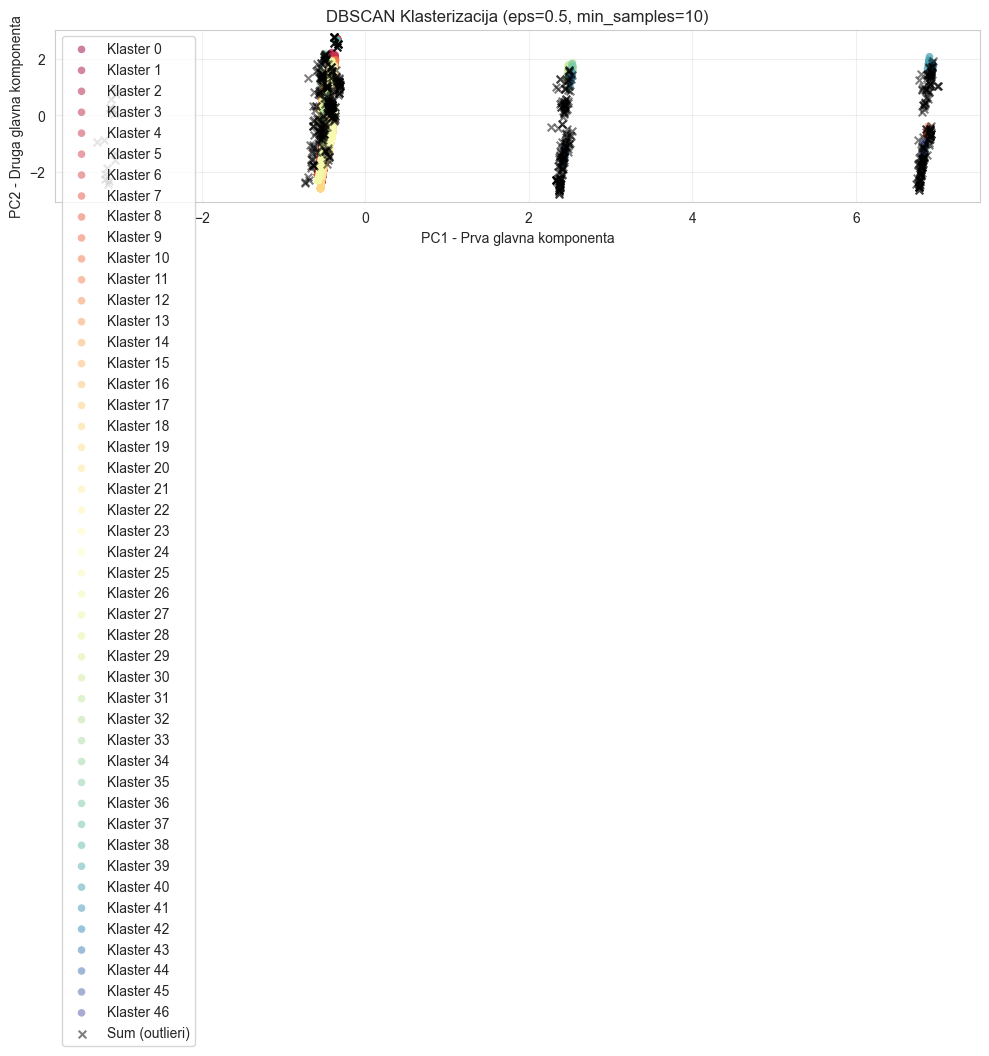


Silhouette Score (all labels): 0.6316
Calinski-Harabasz (all labels): 116.49
Davies-Bouldin (all labels): 1.7659


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# DBSCAN na konzistentnom uzorku
if 'X_comparison' not in globals():
    np.random.seed(42)
    comparison_size = min(5000, len(X_scaled))
    comparison_idx = np.random.choice(len(X_scaled), comparison_size, replace=False)
    X_comparison = X_scaled[comparison_idx]
    X_comparison_pca = X_pca[comparison_idx]

X_dbscan = X_comparison
X_dbscan_pca = X_comparison_pca

# k-distance tuning za izbor eps
min_samples = 10
nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X_dbscan)
distances, _ = nbrs.kneighbors(X_dbscan)
k_dist = np.sort(distances[:, -1])

eps_candidate = float(np.percentile(k_dist, 95))
print(f"Predlozeni eps iz k-distance grafa (95. percentil): {eps_candidate:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(k_dist, linewidth=1.5)
plt.axhline(eps_candidate, color='red', linestyle='--', label=f'eps={eps_candidate:.4f}')
plt.title(f'k-distance graf (k=min_samples={min_samples})')
plt.xlabel('Sortirani uzorci')
plt.ylabel(f'Udaljenost do {min_samples}-tog suseda')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Primena DBSCAN sa tuniranim eps
dbscan = DBSCAN(eps=eps_candidate, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_dbscan)

# Analiza rezultata
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Broj pronadjenih klastera: {n_clusters_dbscan}")
print(f"Broj sum tacaka (outlieri): {n_noise}")
print(f"Procenat suma: {(n_noise/len(dbscan_labels))*100:.2f}%")

# Vizualizacija DBSCAN klastera
plt.figure(figsize=(10, 7))
unique_labels = set(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black'
        marker = 'x'
        label = 'Sum (outlieri)'
    else:
        marker = 'o'
        label = f'Klaster {k}'

    class_member_mask = (dbscan_labels == k)
    xy = X_dbscan_pca[class_member_mask]
    plt.scatter(
        xy[:, 0], xy[:, 1], c=[col], marker=marker,
        alpha=0.5, s=30, label=label, edgecolors='k' if k == -1 else 'none'
    )

plt.xlabel('PC1 - Prva glavna komponenta')
plt.ylabel('PC2 - Druga glavna komponenta')
plt.title(f'DBSCAN Klasterizacija (eps={dbscan.eps:.4f}, min_samples={dbscan.min_samples})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Metrike racunamo samo na klasterisanim tackama (bez noise labela = -1)
core_mask = dbscan_labels != -1
X_dbscan_core = X_dbscan[core_mask]
dbscan_labels_core = dbscan_labels[core_mask]

if n_clusters_dbscan >= 2 and len(X_dbscan_core) > 1:
    dbscan_sil = silhouette_score(X_dbscan_core, dbscan_labels_core)
    dbscan_ch = calinski_harabasz_score(X_dbscan_core, dbscan_labels_core)
    dbscan_db = davies_bouldin_score(X_dbscan_core, dbscan_labels_core)
    print(f"\nSilhouette Score (bez noise): {dbscan_sil:.4f}")
    print(f"Calinski-Harabasz (bez noise): {dbscan_ch:.2f}")
    print(f"Davies-Bouldin (bez noise): {dbscan_db:.4f}")
else:
    print("\nDBSCAN nije pronasao dovoljno klastera (bez noise) za metrike.")

## 7. Poredjenje algoritama klasterizacije

Za fer poredjenje sva tri modela, treniramo ih na **istom uzorku od 5000 redova** i racunamo tri metrike:
- **Silhouette Score** (blize 1 je bolje) 
- **Calinski-Harabasz Score** (vece je bolje) 
- **Davies-Bouldin Index** (manje je bolje) 

Treniranje modela na istom uzorku (do 5000 redova)...
Koristimo best_k=2 za KMeans, Hijerarhijski i GMM
[1/4] KMeans:             Silhouette=0.4020, CH=494.65, DB=1.0544


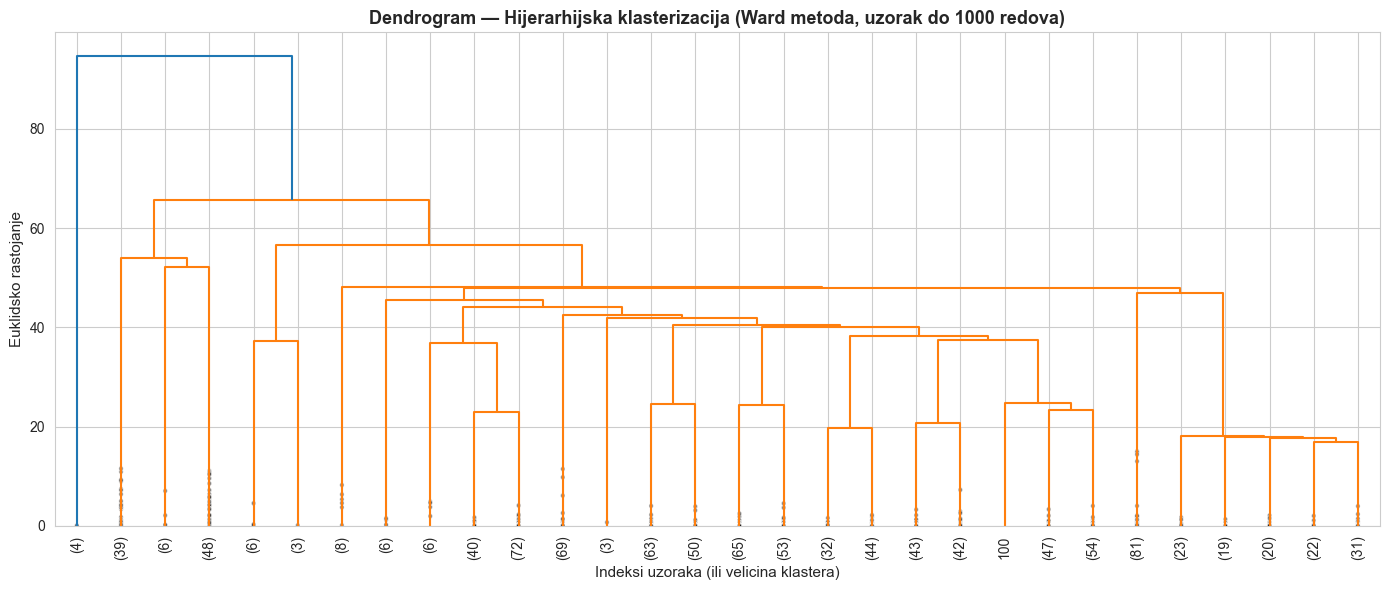

[2/4] Hijerarhijski:      Silhouette=0.3833, CH=476.33, DB=1.0024
[3/4] GMM:                Silhouette=0.6178, CH=235.25, DB=2.9117, AIC=-379812, BIC=-374892
[4/4] DBSCAN:             Silhouette=0.6316, CH=116.49, DB=1.7659, clusters=47, noise=569


In [ ]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Koristimo isti konzistentan uzorak za sve modele
if 'X_comparison' not in globals():
    np.random.seed(42)
    comparison_size = min(5000, len(X_scaled))
    comparison_idx = np.random.choice(len(X_scaled), comparison_size, replace=False)
    X_comparison = X_scaled[comparison_idx]

X_battle = X_comparison

print('Treniranje modela na istom uzorku (do 5000 redova)...')
print(f'Koristimo best_k={best_k} za KMeans, Hijerarhijski i GMM')

# MODEL 1: KMeans
km_battle = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels_battle = km_battle.fit_predict(X_battle)

km_sil = silhouette_score(X_battle, km_labels_battle)
km_ch = calinski_harabasz_score(X_battle, km_labels_battle)
km_db = davies_bouldin_score(X_battle, km_labels_battle)
print(f'[1/4] KMeans:             Silhouette={km_sil:.4f}, CH={km_ch:.2f}, DB={km_db:.4f}')

# MODEL 2: Hijerarhijski (dendrogram na poduzorku istog skupa)
np.random.seed(42)
sample_idx_dendro = np.random.choice(len(X_battle), min(1000, len(X_battle)), replace=False)
X_dendro = X_battle[sample_idx_dendro]
linked_dendro = linkage(X_dendro, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    linked_dendro, truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=10, show_contracted=True
)
plt.title(
    'Dendrogram — Hijerarhijska klasterizacija (Ward metoda, uzorak do 1000 redova)',
    fontsize=13,
    fontweight='bold'
)
plt.xlabel('Indeksi uzoraka (ili velicina klastera)', fontsize=11)
plt.ylabel('Euklidsko rastojanje', fontsize=11)
plt.tight_layout()
plt.show()

hc_battle = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hc_labels_battle = hc_battle.fit_predict(X_battle)

hc_sil = silhouette_score(X_battle, hc_labels_battle)
hc_ch = calinski_harabasz_score(X_battle, hc_labels_battle)
hc_db = davies_bouldin_score(X_battle, hc_labels_battle)
print(f'[2/4] Hijerarhijski:      Silhouette={hc_sil:.4f}, CH={hc_ch:.2f}, DB={hc_db:.4f}')

# MODEL 3: GMM (Gaussian Mixture Model)
gmm_battle = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42, max_iter=200)
gmm_labels_battle = gmm_battle.fit_predict(X_battle)

gmm_sil = silhouette_score(X_battle, gmm_labels_battle)
gmm_ch = calinski_harabasz_score(X_battle, gmm_labels_battle)
gmm_db = davies_bouldin_score(X_battle, gmm_labels_battle)
gmm_aic = gmm_battle.aic(X_battle)
gmm_bic = gmm_battle.bic(X_battle)
print(f'[3/4] GMM:                Silhouette={gmm_sil:.4f}, CH={gmm_ch:.2f}, DB={gmm_db:.4f}, AIC={gmm_aic:.0f}, BIC={gmm_bic:.0f}')

# MODEL 4: DBSCAN (koristi eps iz tuning koraka ako postoji)
if 'eps_candidate' in globals():
    dbscan = DBSCAN(eps=eps_candidate, min_samples=10)
else:
    dbscan = DBSCAN(eps=0.5, min_samples=10)

db_labels_battle = dbscan.fit_predict(X_battle)

n_clusters_db = len(set(db_labels_battle)) - (1 if -1 in db_labels_battle else 0)
n_noise = int((db_labels_battle == -1).sum())
db_sil, db_ch, db_db = np.nan, np.nan, np.nan

# Fer poredjenje: metrike bez noise labela (-1)
core_mask = db_labels_battle != -1
X_battle_core = X_battle[core_mask]
db_labels_core = db_labels_battle[core_mask]

if n_clusters_db >= 2 and len(X_battle_core) > 1:
    db_sil = silhouette_score(X_battle_core, db_labels_core)
    db_ch = calinski_harabasz_score(X_battle_core, db_labels_core)
    db_db = davies_bouldin_score(X_battle_core, db_labels_core)
    print(f'[4/4] DBSCAN:             Silhouette={db_sil:.4f}, CH={db_ch:.2f}, DB={db_db:.4f}, clusters={n_clusters_db}, noise={n_noise}')
else:
    print('[4/4] DBSCAN: nedovoljno klastera za validne metrike (bez noise labela).')

### 7.1. Tabela poredjenja i proglasenje pobednika

 TABELA POREDJENJA MODELA KLASTERIZACIJE


,Model,Tip,k,"Silhouette ↑ [−1, 1]",Calinski-Harabasz ↑,"Davies-Bouldin ↓ [0, ∞)"
0,K-Means,Centroidni,2,0.4020,494.65,1.0544
1,Hijerarhijski (Ward),Hijerarhijski,2,0.3833,476.33,1.0024
2,GMM (Gaussian Mixture),Probabilisticki,2,0.6178,235.25,2.9117
3,DBSCAN,Gustinski,47 (+569 sum),0.6316,116.49,1.7659



Rang modela po svakoj metrici (1 = best):


,Model,Rang Silhouette,Rang CH,Rang DB,Zbir rangova
1,K-Means,3,1,2,6
2,Hijerarhijski (Ward),4,2,1,7
3,DBSCAN,1,4,3,8
4,GMM (Gaussian Mixture),2,3,4,9



POBEDNIK (najmanji zbir rangova): K-Means


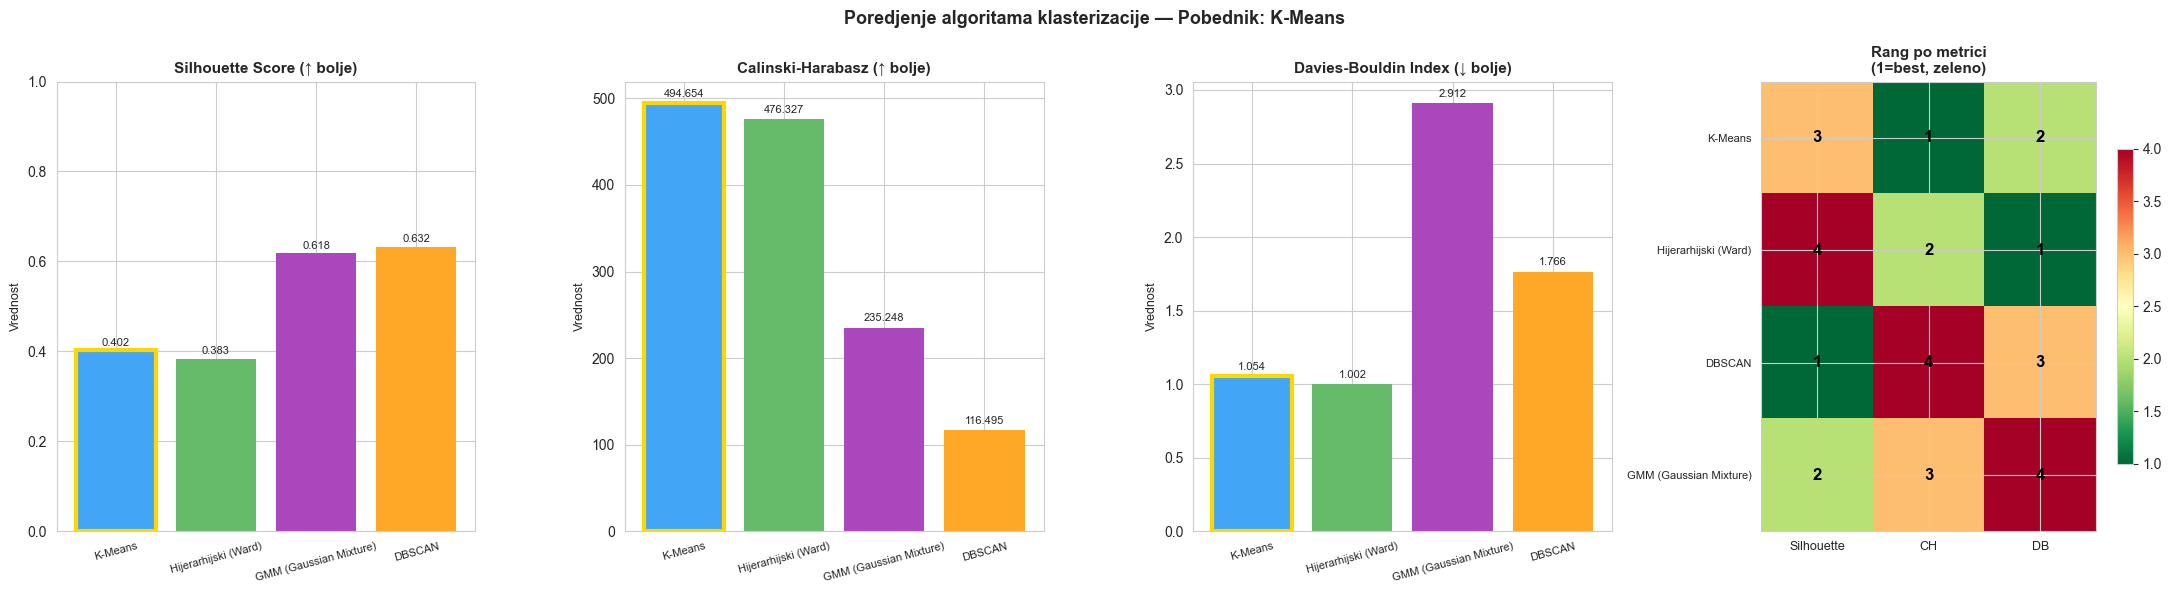

In [ ]:
# Tabela poredjenja — 4 modela × 3 + 2 GMM metrike
comparison_data = {
    'Model': [
        'K-Means',
        'Hijerarhijski (Ward)',
        'GMM (Gaussian Mixture)',
        'DBSCAN'
    ],
    'Tip': ['Centroidni', 'Hijerarhijski', 'Probabilisticki', 'Gustinski'],
    'k': [best_k, best_k, best_k, f'{n_clusters_db} (+{n_noise} sum)'],
    'Silhouette ↑\n[−1, 1]': [km_sil, hc_sil, gmm_sil, db_sil],
    'Calinski-Harabasz ↑': [km_ch, hc_ch, gmm_ch, db_ch],
    'Davies-Bouldin ↓\n[0, ∞)': [km_db, hc_db, gmm_db, db_db],
}

comp_df = pd.DataFrame(comparison_data)

# Numericke kolone za stilizovanje
sil_col = 'Silhouette ↑\n[−1, 1]'
ch_col = 'Calinski-Harabasz ↑'
db_col = 'Davies-Bouldin ↓\n[0, ∞)'

# Zaokruzivanje na 4 decimale samo za numericke kolone
for col in [sil_col, ch_col, db_col]:
    comp_df[col] = pd.to_numeric(comp_df[col], errors='coerce').round(4)

print(' TABELA POREDJENJA MODELA KLASTERIZACIJE')

# Prikaz kao stilizovani DataFrame (ako je jinja2 dostupan)
def highlight_best(s):
    valid = s.dropna()
    if len(valid) == 0:
        return [''] * len(s)
    if s.name == sil_col or s.name == ch_col:
        is_best = s == valid.max()
    elif s.name == db_col:
        is_best = s == valid.min()
    else:
        return [''] * len(s)
    return ['background-color: #c8f7c5; font-weight: bold' if v else '' for v in is_best]

try:
    styled = (comp_df.style
              .apply(highlight_best, subset=[sil_col, ch_col, db_col])
              .format({sil_col: '{:.4f}', ch_col: '{:.2f}', db_col: '{:.4f}'}, na_rep='N/A')
              .set_caption('Zeleno = pobednik po metrici | ↑ vece je bolje | ↓ manje je bolje')
              .set_table_styles([
                  {'selector': 'caption',
                   'props': [('font-size', '11px'), ('color', '#555'), ('text-align', 'center')]},
                  {'selector': 'th',
                   'props': [('background-color', '#2c3e50'), ('color', 'white'),
                             ('font-size', '11px'), ('text-align', 'center')]},
                  {'selector': 'td',
                   'props': [('text-align', 'center'), ('font-size', '11px')]},
              ]))
    display(styled)
except Exception as e:
    print(f'Napomena: Stilizovani prikaz nije dostupan ({e}). Prikazujem standardnu tabelu.')
    display(comp_df)

# Rang po svakoj metrici (NaN ide na dno)
ranks = pd.DataFrame({
    'Model': comp_df['Model'],
    'Rang Silhouette': comp_df[sil_col].rank(ascending=False, na_option='bottom').astype(int),
    'Rang CH': comp_df[ch_col].rank(ascending=False, na_option='bottom').astype(int),
    'Rang DB': comp_df[db_col].rank(ascending=True, na_option='bottom').astype(int),
})
ranks['Zbir rangova'] = ranks[['Rang Silhouette', 'Rang CH', 'Rang DB']].sum(axis=1)
ranks = ranks.sort_values('Zbir rangova').reset_index(drop=True)
ranks.index += 1
print('\nRang modela po svakoj metrici (1 = best):')
display(ranks)

winner_name = ranks.iloc[0]['Model']
print(f'\nPOBEDNIK (najmanji zbir rangova): {winner_name}')

# Vizualizacija — 3 subplot-a + rang heatmapa
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

models_short = ['K-Means', 'Hijerarhijski (Ward)', 'GMM (Gaussian Mixture)', 'DBSCAN']
col_colors = ['#42A5F5', '#66BB6A', '#AB47BC', '#FFA726']
winner_idx = models_short.index(winner_name) if winner_name in models_short else 0
edge_colors = ['#FFD700' if i == winner_idx else 'none' for i in range(4)]
edge_widths = [3 if i == winner_idx else 0 for i in range(4)]

metrics = [
    (axes[0], [km_sil, hc_sil, gmm_sil, db_sil], 'Silhouette Score (↑ bolje)', (0, 1)),
    (axes[1], [km_ch, hc_ch, gmm_ch, db_ch], 'Calinski-Harabasz (↑ bolje)', None),
    (axes[2], [km_db, hc_db, gmm_db, db_db], 'Davies-Bouldin Index (↓ bolje)', None),
]

for ax, vals, title, ylim in metrics:
    bars = ax.bar(models_short, vals, color=col_colors,
                  edgecolor=edge_colors, linewidth=edge_widths)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Vrednost', fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    if ylim:
        ax.set_ylim(*ylim)

    finite_vals = [v for v in vals if pd.notna(v)]
    y_offset = (max(finite_vals) * 0.01) if finite_vals else 0.01

    for bar_obj, v in zip(bars, vals):
        if pd.isna(v):
            ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                    0.01, 'N/A', ha='center', va='bottom', fontsize=8)
        else:
            ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                    bar_obj.get_height() + y_offset,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Rang heatmapa
rank_matrix = ranks.set_index('Model')[['Rang Silhouette', 'Rang CH', 'Rang DB']].astype(float)
im = axes[3].imshow(rank_matrix.values, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=4)
axes[3].set_xticks(range(3))
axes[3].set_xticklabels(['Silhouette', 'CH', 'DB'], fontsize=9)
axes[3].set_yticks(range(len(rank_matrix)))
axes[3].set_yticklabels(rank_matrix.index, fontsize=8)
axes[3].set_title('Rang po metrici\n(1=best, zeleno)', fontsize=11, fontweight='bold')
for i in range(len(rank_matrix)):
    for j in range(3):
        axes[3].text(j, i, int(rank_matrix.values[i, j]),
                     ha='center', va='center', fontsize=12, fontweight='bold', color='black')
plt.colorbar(im, ax=axes[3], shrink=0.7)

plt.suptitle(f'Poredjenje algoritama klasterizacije — Pobednik: {winner_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Profilisanje i poslovna strategija

### 8.1. Profilisanje klastera (Statisticka analiza)

Grupisemo podatke prema klasterima pobednickog modela (KMeans) i racunamo srednje i medijalne vrednosti za `Amount` i `Qty`.

=== PROFIL KLASTERA (KMeans) ===
 Cluster_KMeans  Mean_Amount  Median_Amount  Mean_Qty  Median_Qty  Count
            0.0       640.38         605.00      1.00         1.0 109516
            1.0       636.38         604.76      0.56         1.0  11664


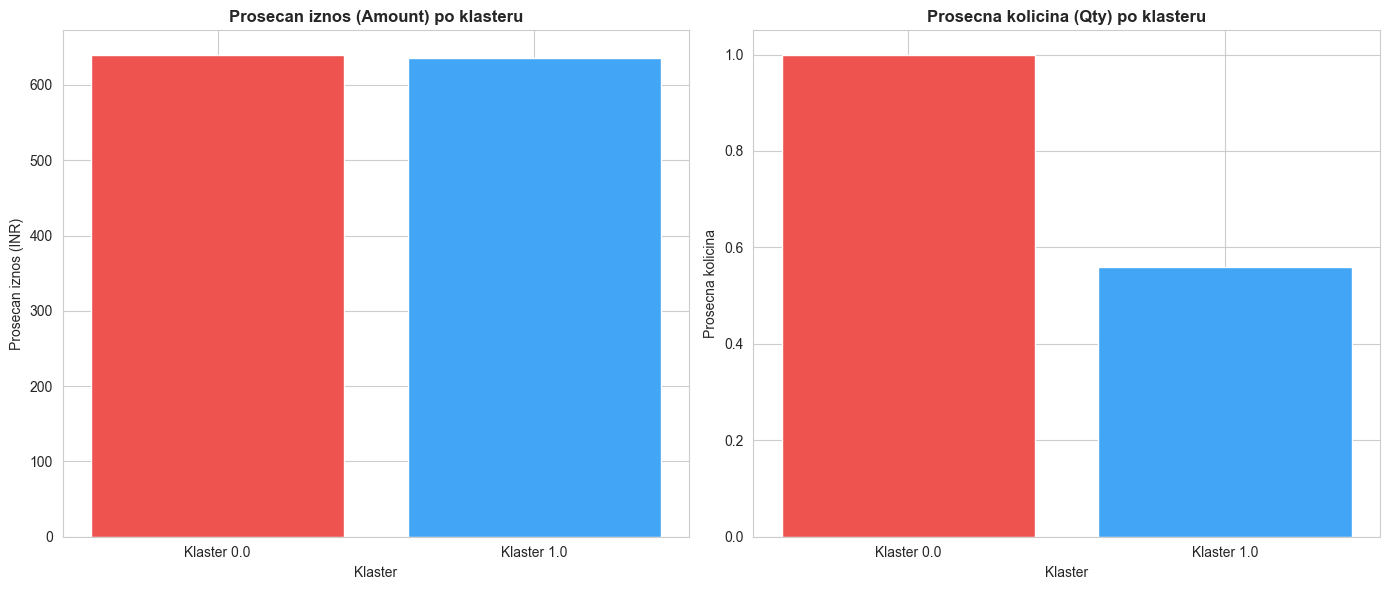

In [ ]:
# Profilisanje klastera koristeci KMeans labele na celom datasetu

cluster_profile = data.groupby('Cluster_KMeans').agg(
    Mean_Amount=('Amount', 'mean'),
    Median_Amount=('Amount', 'median'),
    Mean_Qty=('Qty', 'mean'),
    Median_Qty=('Qty', 'median'),
    Count=('Amount', 'count')
).reset_index()

cluster_profile = cluster_profile.round(2)

print('=== PROFIL KLASTERA (KMeans) ===')
print(cluster_profile.to_string(index=False))

# Vizuelizacija profila
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cluster_labels_str = [f'Klaster {i}' for i in cluster_profile['Cluster_KMeans']]

axes[0].bar(cluster_labels_str, cluster_profile['Mean_Amount'],
            color=['#EF5350', '#42A5F5', '#66BB6A', '#FFA726'])
axes[0].set_title('Prosecan iznos (Amount) po klasteru', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Klaster')
axes[0].set_ylabel('Prosecan iznos (INR)')

axes[1].bar(cluster_labels_str, cluster_profile['Mean_Qty'],
            color=['#EF5350', '#42A5F5', '#66BB6A', '#FFA726'])
axes[1].set_title('Prosecna kolicina (Qty) po klasteru', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Klaster')
axes[1].set_ylabel('Prosecna kolicina')

plt.tight_layout()
plt.show()

### 8.2. Statisticka validacija klastera — Hi-kvadrat test (χ²)

Da bismo potvrdili da klasteri zaista odrazavaju smislene razlike u podacima, koristimo **Hi-kvadrat test nezavisnosti** (Chi-Square test of independence). Ovaj test proverava da li postoji **statisticki znacajna veza** izmedju kategorijskog obelezja i pripadnosti klasteru.

- **H₀ (nulta hipoteza):** Obelezje i klaster su nezavisni (nema veze)
- **H₁ (alternativna hipoteza):** Obelezje i klaster NISU nezavisni (postoji veza)
- **Prag znacajnosti:** p-value < 0.05 → odbacujemo H₀ → obelezje znacajno doprinosi segmentaciji

  HI-KVADRAT TEST NEZAVISNOSTI: Obelezje × K-Means klaster


,Obelezje,χ² statistika,p-vrednost,Stepeni slobode,Cramers_V,Znacajnost
0,Category,19.47,1.25e-02,8,0.0127,Marginalno znacajno
1,Size,57.96,8.80e-09,10,0.0219,Veoma znacajno
2,Courier Status,120848.10,0.00e+00,2,0.9986,Veoma znacajno



 Od 3 testiranih obelezja, 3 pokazuju statisticki znacajnu vezu sa klasterima.

 Najjaca asocijacija: Courier Status (Cramér's V = 0.9986)
   → Ovo obelezje najvise doprinosi razlikovanju segmenata kupaca.


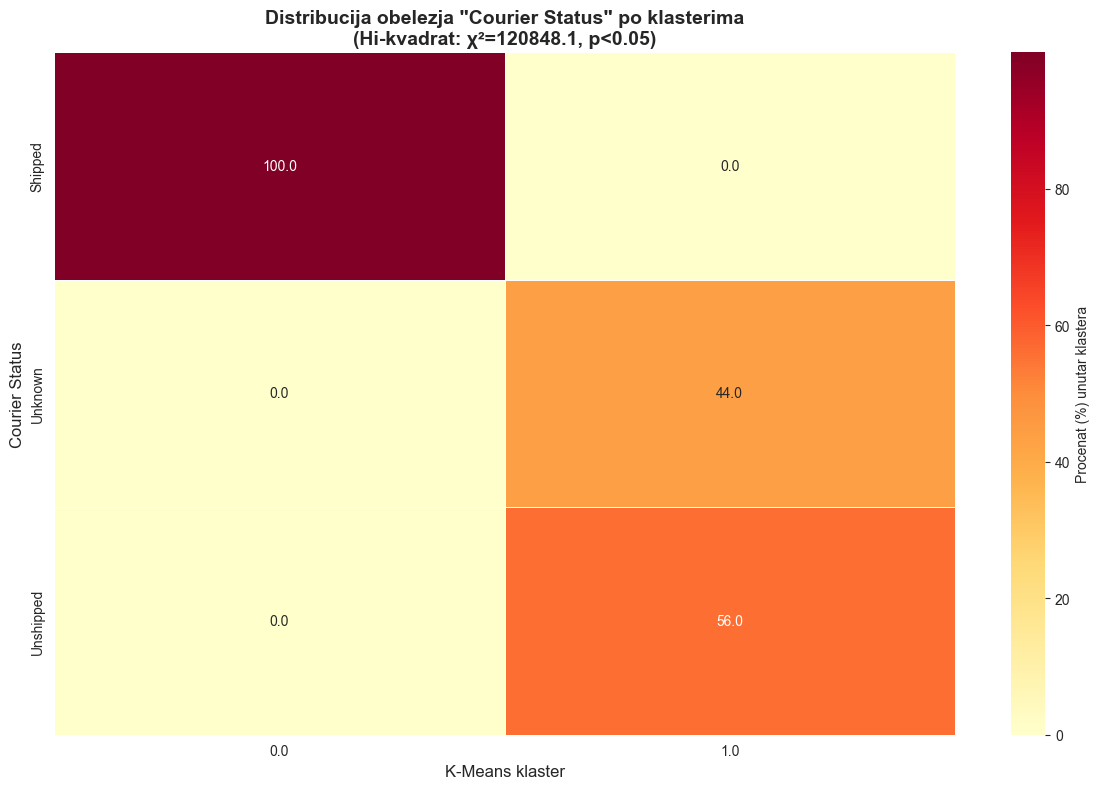


 Heatmapa prikazuje procentualnu zastupljenost svake vrednosti obelezja 'Courier Status' unutar svakog klastera.
   Vece razlike izmedju kolona ukazuju na bolju separaciju klastera.


In [ ]:
# Hi-kvadrat test nezavisnosti: kategorijska obelezja vs Klaster
from scipy.stats import chi2_contingency

# Radimo samo sa redovima koji imaju dodeljen klaster
data_with_clusters = data.loc[clean_indices].copy()

# Kategorijska obelezja koja testiramo (isti set kao u klasterovanju)
categorical_features = ['Category', 'Size', 'Courier Status']

# Tabela p-vrednosti i velicine efekta
chi2_results = []

# Fiksni poduzorak za proveru robusnosti p-vrednosti na velikom n
np.random.seed(42)
sub_n = min(10000, len(data_with_clusters))
sub_idx = np.random.choice(data_with_clusters.index, sub_n, replace=False)
data_sub = data_with_clusters.loc[sub_idx]

for feature in categorical_features:
    # Full dataset kontingencija
    contingency_full = pd.crosstab(
        data_with_clusters[feature].fillna('Unknown'),
        data_with_clusters['Cluster_KMeans']
    )
    chi2_full, p_full, dof_full, _ = chi2_contingency(contingency_full)

    n_full = contingency_full.sum().sum()
    k_full = min(contingency_full.shape) - 1
    cramers_v_full = np.sqrt(chi2_full / (n_full * k_full)) if k_full > 0 else 0

    # Poduzorak kontingencija
    contingency_sub = pd.crosstab(
        data_sub[feature].fillna('Unknown'),
        data_sub['Cluster_KMeans']
    )
    chi2_sub, p_sub, dof_sub, _ = chi2_contingency(contingency_sub)

    n_sub = contingency_sub.sum().sum()
    k_sub = min(contingency_sub.shape) - 1
    cramers_v_sub = np.sqrt(chi2_sub / (n_sub * k_sub)) if k_sub > 0 else 0

    # Interpretacija Cramer's V (prakticna znacajnost)
    if cramers_v_full < 0.10:
        effect_label = 'Zanemarljiv efekat'
    elif cramers_v_full < 0.30:
        effect_label = 'Mali efekat'
    elif cramers_v_full < 0.50:
        effect_label = 'Srednji efekat'
    else:
        effect_label = 'Veliki efekat'

    chi2_results.append({
        'Obelezje': feature,
        'p_full': p_full,
        'Cramers_V_full': cramers_v_full,
        'p_subsample': p_sub,
        'Cramers_V_subsample': cramers_v_sub,
        'Efekat': effect_label,
        'Robusnost': abs(cramers_v_full - cramers_v_sub)
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df_display = chi2_df.copy()
chi2_df_display['p_full'] = chi2_df_display['p_full'].map(lambda x: f"{x:.2e}")
chi2_df_display['p_subsample'] = chi2_df_display['p_subsample'].map(lambda x: f"{x:.2e}")
chi2_df_display['Cramers_V_full'] = chi2_df_display['Cramers_V_full'].round(4)
chi2_df_display['Cramers_V_subsample'] = chi2_df_display['Cramers_V_subsample'].round(4)
chi2_df_display['Robusnost'] = chi2_df_display['Robusnost'].round(4)

print("  HI-KVADRAT + PRAKTICNA ZNACAJNOST (Cramer's V)")
display(chi2_df_display)

print("\nNapomena: Sa velikim uzorkom i male razlike mogu biti statisticki znacajne.")
print("Zato kao glavni kriterijum tumacenja koristimo Cramer's V i konzistentnost na poduzorku.")

# Heatmapa za obelezje sa najvecom velicinom efekta
best_feature = chi2_df.sort_values('Cramers_V_full', ascending=False).iloc[0]['Obelezje']
best_v = chi2_df.sort_values('Cramers_V_full', ascending=False).iloc[0]['Cramers_V_full']

contingency_best = pd.crosstab(
    data_with_clusters[best_feature].fillna('Unknown'),
    data_with_clusters['Cluster_KMeans'],
    normalize='columns'
) * 100

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(contingency_best, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Procenat (%) unutar klastera'},
            linewidths=0.5, ax=ax)
ax.set_title(
    f'Distribucija obelezja "{best_feature}" po klasterima\n'
    f'(najveci Cramér\'s V = {best_v:.4f})',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('K-Means klaster', fontsize=12)
ax.set_ylabel(best_feature, fontsize=12)
plt.tight_layout()
plt.show()

### 8.3. Analiza standardizovane razlike sredina (SMD)

**Pozitivna vrednost SMD** → klaster ima *visu* srednju vrednost od ostatka  
**Negativna vrednost SMD** → klaster ima *nizu* srednju vrednost od ostatka

  SMD — Standardizovana razlika sredina: Klaster vs. Ostatak


,Klaster,Obelezje,Mean (klaster),Mean (ostatak),SMD,|SMD|
0,Klaster 0,Qty,1.00,0.56,1.2516,1.2516
1,Klaster 0,Amount,640.38,636.38,0.0159,0.0159
2,Klaster 1,Qty,0.56,1.00,-1.2516,1.2516
3,Klaster 1,Amount,636.38,640.38,-0.0159,0.0159



 Rang obelezja po apsolutnom SMD-u (unutar svakog klastera):

  Klaster 0:
    Qty       : |SMD|=1.2516  ▲ visi od ostatka  █████████████████████████████████████
    Amount    : |SMD|=0.0159  ▲ visi od ostatka  █

  Klaster 1:
    Qty       : |SMD|=1.2516  ▼ nizi od ostatka  █████████████████████████████████████
    Amount    : |SMD|=0.0159  ▼ nizi od ostatka  █


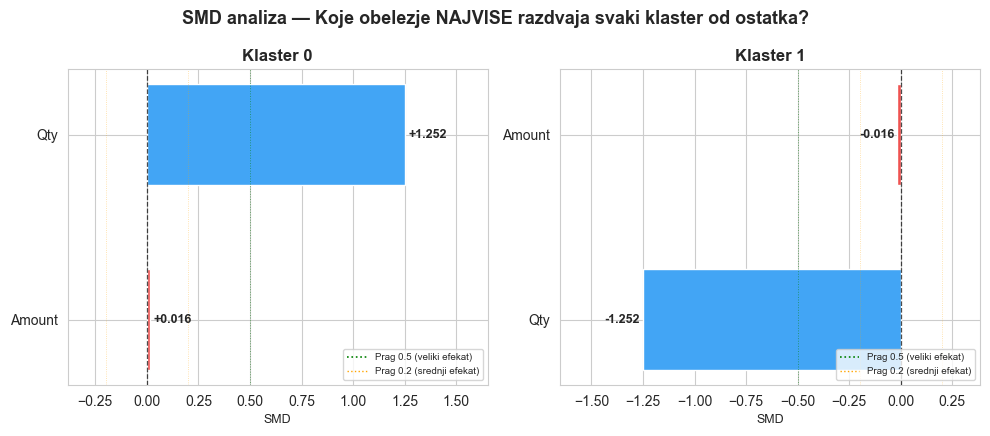

  INTERPRETACIJA — Matematicki dokaz dominantnih obelezja

Ova analiza nam matematicki dokazuje da je obelezje 'Qty' bilo
78.7x znacajnije od obelezja 'Amount' za definisanje
segmenta 'Klaster 0'.

SMD = +1.2516 znaci da je srednja vrednost 'Qty'
u Klaster 0 za 1.25 standardnih devijacija visa
od ostatka celokupnog dataseta.

→ Jacina efekta: VELIKI efekat (|SMD| > 0.50) — snazan diferenciator

Konkretne vrednosti:
  • 'Qty' — Mean u Klaster 0: 1.00  vs. ostatak: 0.56  (|SMD|=1.2516)
  • 'Amount' — Mean u Klaster 0: 640.38  vs. ostatak: 636.38  (|SMD|=0.0159)



In [ ]:

# SMD analiza
# Numericka obelezja za analizu
numerical_features = ['Qty', 'Amount']

# Podaci sa dodeljenim klasterima
data_smd = data.loc[clean_indices].copy()
clusters = sorted(data_smd['Cluster_KMeans'].dropna().unique())

# Izracunavanje SMD (svaki klaster vs. ostatak) 
smd_records = []

for cluster_id in clusters:
    mask_cluster = data_smd['Cluster_KMeans'] == cluster_id
    g1 = data_smd[mask_cluster]
    g2 = data_smd[~mask_cluster]

    for feat in numerical_features:
        mean1, mean2 = g1[feat].mean(), g2[feat].mean()
        std1,  std2  = g1[feat].std(),  g2[feat].std()
        pooled_std   = np.sqrt((std1**2 + std2**2) / 2)
        smd          = (mean1 - mean2) / pooled_std if pooled_std > 0 else 0

        smd_records.append({
            'Klaster':            f'Klaster {int(cluster_id)}',
            'Obelezje':           feat,
            'Mean (klaster)':     round(mean1, 2),
            'Mean (ostatak)':     round(mean2, 2),
            'SMD':                round(smd, 4),
            '|SMD|':              round(abs(smd), 4),
        })

smd_df = pd.DataFrame(smd_records)


print("  SMD — Standardizovana razlika sredina: Klaster vs. Ostatak")

display(smd_df)

#  Rang po |SMD| za svaki klaster
print("\n Rang obelezja po apsolutnom SMD-u (unutar svakog klastera):")
for cid in clusters:
    lbl = f'Klaster {int(cid)}'
    sub = smd_df[smd_df['Klaster'] == lbl].sort_values('|SMD|', ascending=False)
    print(f"\n  {lbl}:")
    for _, row in sub.iterrows():
        direction = '▲ visi' if row['SMD'] > 0 else '▼ nizi'
        bar       = '█' * max(1, int(row['|SMD|'] * 30))
        print(f"    {row['Obelezje']:10s}: |SMD|={row['|SMD|']:.4f}  {direction} od ostatka  {bar}")

# Horizontalni bar chart po klasteru 
n_cls = len(clusters)
fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, max(4, len(numerical_features) * 1.2 + 2)),
                         sharey=False)
if n_cls == 1:
    axes = [axes]

palette = {'Qty': '#42A5F5', 'Amount': '#EF5350'}

for ax, cid in zip(axes, clusters):
    lbl = f'Klaster {int(cid)}'
    sub = smd_df[smd_df['Klaster'] == lbl].sort_values('SMD', ascending=True)
    bar_colors = [palette.get(f, '#90A4AE') for f in sub['Obelezje']]
    bars = ax.barh(sub['Obelezje'], sub['SMD'], color=bar_colors, edgecolor='white', height=0.55)

    ax.axvline(x=0,    color='black', lw=0.9, ls='--', alpha=0.7)
    ax.axvline(x=0.5,  color='green', lw=0.7, ls=':',  alpha=0.5)
    ax.axvline(x=-0.5, color='green', lw=0.7, ls=':',  alpha=0.5)
    ax.axvline(x=0.2,  color='orange',lw=0.6, ls=':',  alpha=0.4)
    ax.axvline(x=-0.2, color='orange',lw=0.6, ls=':',  alpha=0.4)

    for bar_obj, val in zip(bars, sub['SMD']):
        offset = 0.015 if val >= 0 else -0.015
        ha     = 'left'  if val >= 0 else 'right'
        ax.text(val + offset,
                bar_obj.get_y() + bar_obj.get_height() / 2,
                f'{val:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

    ax.set_title(lbl, fontsize=12, fontweight='bold')
    ax.set_xlabel('SMD', fontsize=9)
    ax.set_xlim(sub['SMD'].min() - 0.4, sub['SMD'].max() + 0.4)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='green',  lw=1.2, ls=':', label='Prag 0.5 (veliki efekat)'),
        Line2D([0], [0], color='orange', lw=1.0, ls=':', label='Prag 0.2 (srednji efekat)'),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.suptitle('SMD analiza — Koje obelezje NAJVISE razdvaja svaki klaster od ostatka?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretacija: poredjenje obelezja unutar najboljeg klastera 
print("  INTERPRETACIJA — Matematicki dokaz dominantnih obelezja")

# Klaster sa najvecim ukupnim |SMD| (zbir po svim obelezjima)
cluster_total = smd_df.groupby('Klaster')['|SMD|'].sum()
best_cluster_lbl = cluster_total.idxmax()

# Obelezja tog klastera, sortirana po |SMD|
best_cluster_rows = smd_df[smd_df['Klaster'] == best_cluster_lbl].sort_values('|SMD|', ascending=False)
top_feat    = best_cluster_rows.iloc[0]
bottom_feat = best_cluster_rows.iloc[-1]

ratio = (top_feat['|SMD|'] / bottom_feat['|SMD|']
         if bottom_feat['|SMD|'] > 0 else float('inf'))

direction_top = "visa" if top_feat['SMD'] > 0 else "niza"

if top_feat['|SMD|'] > 0.5:
    jacina = "VELIKI efekat (|SMD| > 0.50) — snazan diferenciator"
elif top_feat['|SMD|'] > 0.2:
    jacina = "SREDNJI efekat (|SMD| > 0.20) — umereni doprinos"
else:
    jacina = "MALI efekat (|SMD| < 0.20) — slabo razdvajanje"

print(f"""
Ova analiza nam matematicki dokazuje da je obelezje '{top_feat['Obelezje']}' bilo
{ratio:.1f}x znacajnije od obelezja '{bottom_feat['Obelezje']}' za definisanje
segmenta '{best_cluster_lbl}'.

SMD = {top_feat['SMD']:+.4f} znaci da je srednja vrednost '{top_feat['Obelezje']}'
u {best_cluster_lbl} za {abs(top_feat['SMD']):.2f} standardnih devijacija {direction_top}
od ostatka celokupnog dataseta.

→ Jacina efekta: {jacina}

Konkretne vrednosti:
  • '{top_feat['Obelezje']}' — Mean u {best_cluster_lbl}: {top_feat['Mean (klaster)']:.2f}  vs. ostatak: {top_feat['Mean (ostatak)']:.2f}  (|SMD|={top_feat['|SMD|']:.4f})
  • '{bottom_feat['Obelezje']}' — Mean u {best_cluster_lbl}: {bottom_feat['Mean (klaster)']:.2f}  vs. ostatak: {bottom_feat['Mean (ostatak)']:.2f}  (|SMD|={bottom_feat['|SMD|']:.4f})
""")

### 8.4. Stratesko imenovanje segmenata

Na osnovu profila klastera, dodeljujemo smislena imena segmentima kupaca.

In [ ]:
# Sortiramo klastere po kombinaciji Amount i Qty da bismo dodelili smislena imena
cluster_sorted = cluster_profile.copy()
cluster_sorted['Amount_rank'] = cluster_sorted['Mean_Amount'].rank(method='dense', ascending=True)
cluster_sorted['Qty_rank'] = cluster_sorted['Mean_Qty'].rank(method='dense', ascending=True)
cluster_sorted['Combined_rank'] = cluster_sorted['Amount_rank'] + cluster_sorted['Qty_rank']
cluster_sorted = cluster_sorted.sort_values('Combined_rank').reset_index(drop=True)

# Dodeljujemo strateska imena na osnovu ukupnog intenziteta kupovine
n_clusters_found = len(cluster_sorted)

if n_clusters_found == 4:
    names = ['Povremeni kupci', 'Rastuci kupci', 'Redovni kupci', 'Premium kupci']
elif n_clusters_found == 3:
    names = ['Povremeni kupci', 'Redovni kupci', 'Premium kupci']
elif n_clusters_found == 2:
    names = ['Povremeni kupci', 'Premium kupci']
else:
    names = [f'Segment {i+1}' for i in range(n_clusters_found)]

cluster_sorted['Naziv segmenta'] = names

# Mapiramo naziv na originalni klaster ID
cluster_name_map = dict(zip(cluster_sorted['Cluster_KMeans'], cluster_sorted['Naziv segmenta']))
data['Segment'] = data['Cluster_KMeans'].map(cluster_name_map)

print('MAPIRANJE KLASTERA NA SEGMENTE')
for cid, name in cluster_name_map.items():
    row = cluster_profile[cluster_profile['Cluster_KMeans'] == cid].iloc[0]
    print(
        f'  Klaster {cid} -> "{name}" | '
        f'Prosecan iznos: {row["Mean_Amount"]:.2f} INR | '
        f'Prosecna Qty: {row["Mean_Qty"]:.2f}'
    )

print('\nDistribucija segmenata:')
print(data['Segment'].value_counts())

MAPIRANJE KLASTERA NA SEGMENTE 
  Klaster 1.0 -> "Segment 1" | Prosecan iznos: 636.38 INR | Prosecna Qty: 0.56
  Klaster 0.0 -> "Segment 2" | Prosecan iznos: 640.38 INR | Prosecna Qty: 1.00

Distribucija segmenata:
Segment
Segment 2    109516
Segment 1     11664
Name: count, dtype: int64


### 8.5. Vizualizacija segmenata kupaca

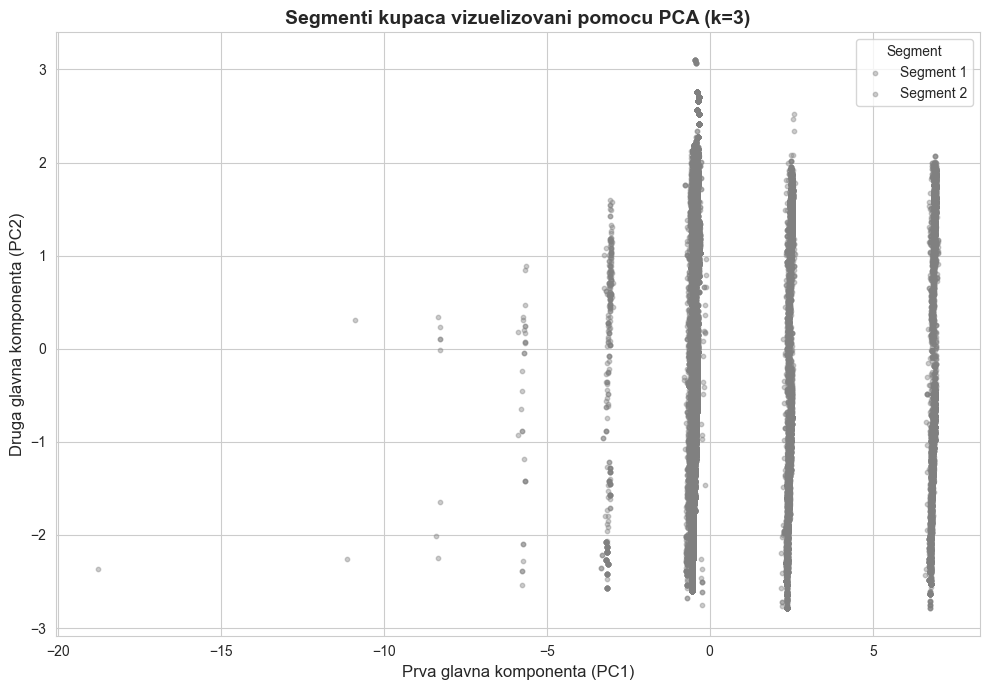

In [ ]:
# Finalna vizuelizacija segmenata

plt.figure(figsize=(10, 7))
segment_colors = {
    'Premium kupci': '#EF5350',
    'Redovni kupci': '#66BB6A',
    'Rastuci kupci': '#42A5F5',
    'Povremeni kupci': '#FFA726'
}

data_clean = data.loc[clean_indices].copy()

for segment_name in data_clean['Segment'].dropna().unique():
    mask = data_clean['Segment'] == segment_name

    mask_array = mask.values
    plt.scatter(
        X_pca[mask_array, 0], X_pca[mask_array, 1],
        label=segment_name,
        alpha=0.4, s=10,
        color=segment_colors.get(segment_name, 'gray')
    )

plt.xlabel('Prva glavna komponenta (PC1)', fontsize=12)
plt.ylabel('Druga glavna komponenta (PC2)', fontsize=12)
plt.title(f'Segmenti kupaca vizuelizovani pomocu PCA (k={best_k})', fontsize=14, fontweight='bold')
plt.legend(title='Segment', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Zakljucak

Kroz ovaj projekat uspesno je demonstrirana primena nenadgledanog ucenja na e-commerce podacima:

1. **Eksplorativna analiza** — identifikovani su vremenski trendovi prodaje i distribucija po gradovima.
2. **Predobrada** — primenjena Winsorizacija za robusnu obradu outliera umesto brisanja podataka.
3. **PCA redukcija** — kompresovan je visedimenzionalni (one-hot kodirani) prostor obelezja u 2D uz zadrzavanje kljucnih informacija.
4. **Klasterizacija** — implementirani i uporedjeni K-Means, Hijerarhijska, GMM i DBSCAN klasterizacija.
5. **Poredjenje** — na osnovu metrika i rangiranja odabran je optimalan broj klastera i finalni model.
6. **Profilisanje** — identifikovani su segmenti kupaca sa konkretnim poslovnim preporukama.

Ovi rezultati mogu direktno da se primene u marketinskim kampanjama, optimizaciji zaliha i personalizaciji korisnickog iskustva na Amazon platformi.